In [1]:
import os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results_table = pq.read_table('results/872_shared_total/model_to_model.parquet')
model_comp = results_table.to_pandas()

In [3]:
model_comp_table = pq.read_table('results/872_shared_total/model_comparison/rsa_model_comp_all.parquet')
brain_comp = model_comp_table.to_pandas()

In [4]:
roi = "PPA"
best_layer_df = brain_comp.loc[(brain_comp["ROI"]==roi) & 
(brain_comp["crop_size"]==224) & 
(brain_comp["center_crop"]==False),:]

In [5]:
#groups = model_comp.groupby("time_window_1")
#group = groups.get_group(5) 
group = model_comp.copy()

In [6]:
group = group[group[["time_window_1", "Layer_1"]].apply(tuple, axis=1).isin(best_layer_df[["time_window", "Layer"]].apply(tuple, axis=1))]
group = group[group[["time_window_2", "Layer_2"]].apply(tuple, axis=1).isin(best_layer_df[["time_window", "Layer"]].apply(tuple, axis=1))]

In [9]:
model_groups = group.groupby("model")
pivot_resnet50 = model_groups.get_group("resnet50").pivot_table(index="time_window_1", columns="time_window_2", values="R")
pivot_vit_base = model_groups.get_group("vit_base").pivot_table(index="time_window_1", columns="time_window_2", values="R")

Text(0.5, 1.0, 'vit_base')

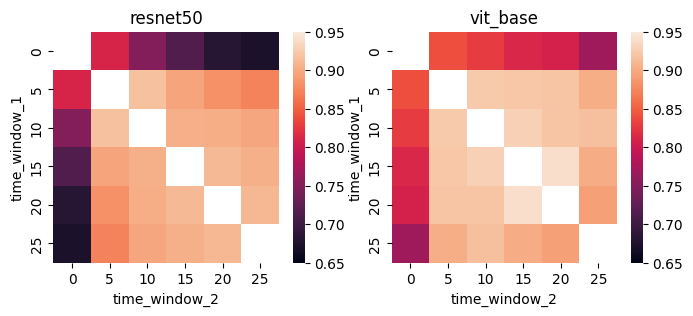

In [24]:
fig, axs = plt.subplots(1,2, figsize=(8,3))
sns.heatmap(pivot_resnet50, ax=axs[0], cmap="rocket", vmin=0.65, vmax=0.95)
axs[0].set_title("resnet50")
sns.heatmap(pivot_vit_base, ax=axs[1], cmap="rocket", vmin=0.65, vmax=0.95)
axs[1].set_title("vit_base")